

 GLOBAL HAPPINESS REPORT ANALYSIS 
1. Load Dataset
2. Explore Dataset
3. Handle Missing Values
4. Descriptive Statistics
5. Top 10 Happiest Countries
6. Correlation Heatmap
7. Life Expectancy vs Happiness
8. Save Cleaned Dataset
9. Exit

Enter your choice: 1

✅ Dataset Loaded Successfully!

       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553      

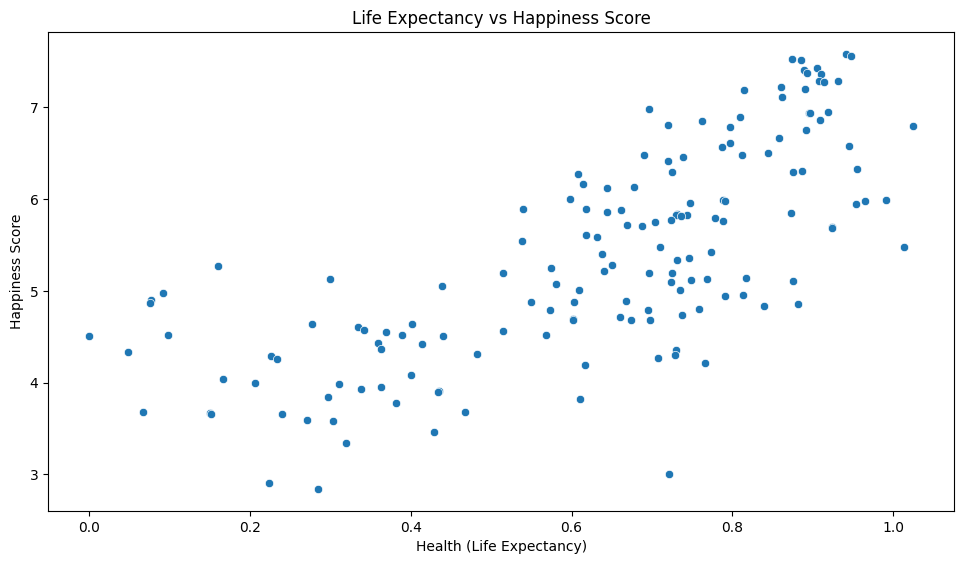



 GLOBAL HAPPINESS REPORT ANALYSIS 
1. Load Dataset
2. Explore Dataset
3. Handle Missing Values
4. Descriptive Statistics
5. Top 10 Happiest Countries
6. Correlation Heatmap
7. Life Expectancy vs Happiness
8. Save Cleaned Dataset
9. Exit


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


class HappinessAnalysis:

    def __init__(self):


        self.file_path = "/content/World Happiness Report.csv"

        self.df = None

    def load_dataset(self):

        try:

            self.df = pd.read_csv(self.file_path)

            print("\n✅ Dataset Loaded Successfully!\n")

            print(self.df.head())

            print(f"\nDataset Shape: {self.df.shape}")

        except FileNotFoundError:
            print("❌ File not found.")

        except Exception as e:
            print(f"❌ Error: {e}")

    def explore_dataset(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\n========== DATASET INFO ==========")
        print(self.df.info())

        print("\n========== FIRST 5 ROWS ==========")
        print(self.df.head())

        print("\n========== LAST 5 ROWS ==========")
        print(self.df.tail())

        print("\n========== SHAPE ==========")
        print(self.df.shape)

        print("\n========== COLUMN NAMES ==========")
        print(self.df.columns.tolist())

        print("\n========== MISSING VALUES ==========")
        print(self.df.isnull().sum())

    def handle_missing_values(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\nMissing Values Before Cleaning:\n")
        print(self.df.isnull().sum())

        numeric_cols = self.df.select_dtypes(include=np.number).columns

        for col in numeric_cols:

            self.df[col] = self.df[col].fillna(
                self.df[col].mean()
            )

        print("\n✅ Missing values handled successfully.")

        print("\nMissing Values After Cleaning:\n")
        print(self.df.isnull().sum())

    def descriptive_statistics(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        print("\n========== DESCRIPTIVE STATISTICS ==========")

        print(self.df.describe())

    def top_happiest_countries(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        possible_columns = [
            "Score",
            "Happiness Score",
            "Ladder score"
        ]

        score_column = None

        for col in possible_columns:
            if col in self.df.columns:
                score_column = col
                break

        if score_column is None:
            print("❌ Happiness score column not found.")
            return

        top_10 = self.df.sort_values(
            by=score_column,
            ascending=False
        ).head(10)

        print("\n========== TOP 10 HAPPIEST COUNTRIES ==========")

        print(top_10[["Country", score_column]])

        plt.figure(figsize=(12, 6))

        sns.barplot(
            x=top_10["Country"],
            y=top_10[score_column]
        )

        plt.title("Top 10 Happiest Countries")

        plt.xticks(rotation=45)

        plt.tight_layout(pad=2.0)

        plt.show()

    def correlation_heatmap(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        numeric_df = self.df.select_dtypes(include=np.number)

        plt.figure(figsize=(12, 8))

        sns.heatmap(
            numeric_df.corr(),
            annot=True,
            cmap='coolwarm'
        )

        plt.title("Correlation Heatmap")

        plt.tight_layout(pad=2.0)

        plt.show()

    def life_expectancy_vs_happiness(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        happiness_cols = [
            "Score",
            "Happiness Score",
            "Ladder score"
        ]

        life_cols = [
            "Health (Life Expectancy)",
            "Healthy life expectancy at birth"
        ]

        happiness_col = None
        life_col = None

        for col in happiness_cols:
            if col in self.df.columns:
                happiness_col = col
                break

        for col in life_cols:
            if col in self.df.columns:
                life_col = col
                break

        if happiness_col is None or life_col is None:
            print("❌ Required columns not found.")
            return

        plt.figure(figsize=(10, 6))

        sns.scatterplot(
            x=self.df[life_col],
            y=self.df[happiness_col]
        )

        plt.title("Life Expectancy vs Happiness Score")

        plt.xlabel(life_col)
        plt.ylabel(happiness_col)

        plt.tight_layout(pad=2.0)

        plt.show()

    def save_dataset(self):

        if self.df is None:
            print("⚠ Please load dataset first.")
            return

        output_file = "cleaned_happiness_report.csv"

        self.df.to_csv(output_file, index=False)

        print(f"\n✅ Dataset saved as {output_file}")


def main():

    analyzer = HappinessAnalysis()

    while True:

        print("\n")
        print("=" * 60)
        print(" GLOBAL HAPPINESS REPORT ANALYSIS ")
        print("=" * 60)

        print("1. Load Dataset")
        print("2. Explore Dataset")
        print("3. Handle Missing Values")
        print("4. Descriptive Statistics")
        print("5. Top 10 Happiest Countries")
        print("6. Correlation Heatmap")
        print("7. Life Expectancy vs Happiness")
        print("8. Save Cleaned Dataset")
        print("9. Exit")

        choice = input("\nEnter your choice: ")

        if choice == '1':
            analyzer.load_dataset()

        elif choice == '2':
            analyzer.explore_dataset()

        elif choice == '3':
            analyzer.handle_missing_values()

        elif choice == '4':
            analyzer.descriptive_statistics()

        elif choice == '5':
            analyzer.top_happiest_countries()

        elif choice == '6':
            analyzer.correlation_heatmap()

        elif choice == '7':
            analyzer.life_expectancy_vs_happiness()

        elif choice == '8':
            analyzer.save_dataset()

        elif choice == '9':

            print("\n✅ Exiting Program...")

            break

        else:
            print("❌ Invalid choice.")

if __name__ == "__main__":
    main()